<a href="https://colab.research.google.com/github/Monkey-yue/Python-Learning/blob/main/Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print(' Libiraries loaded successfully')

 Libiraries loaded successfully


In [2]:
'''
show the first row of Iris' table
'''
iris = load_iris()

X = iris.data
y = iris.target

print('Feature matrix shape:' ,X.shape)
print( 'Label vector shape:', y.shape)
print('Feature names:', iris.feature_names)
print('Class names:', iris.target_names)

print('First 5 row of X:')
print(X[:5])
print('First 5 labels:', y[:5])


Feature matrix shape: (150, 4)
Label vector shape: (150,)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class names: ['setosa' 'versicolor' 'virginica']
First 5 row of X:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
First 5 labels: [0 0 0 0 0]


In [3]:
'''
训练集和测试集规划
'''
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.2, random_state=42
)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 30
Testing samples: 120


Training Accuracy:1.000
Testing Accuracy: 0.967


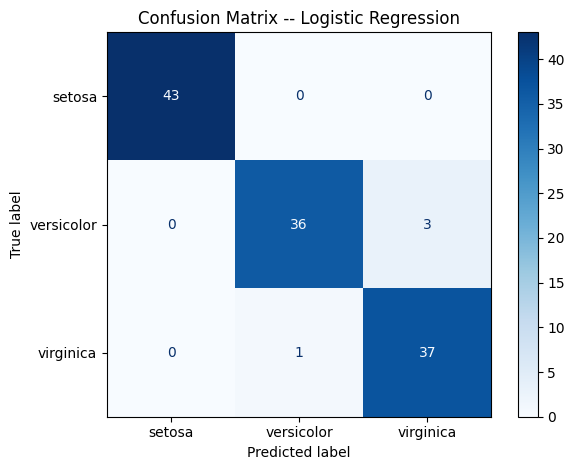

In [4]:
model_lr = LogisticRegression(max_iter=200)
model_lr.fit(X_train, y_train)
train_acc = model_lr.score(X_train, y_train)
test_acc = model_lr.score(X_test, y_test)

print(f'Training Accuracy:{train_acc:.3f}')
print(f'Testing Accuracy: {test_acc:.3f}')

#Confusion matrix#

y_pred = model_lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
disp.plot(cmap="Blues")
plt.title('Confusion Matrix -- Logistic Regression')
plt.tight_layout()
plt.show()

Confusion matrix : 混淆矩阵 直观地了解模型在各个类别上的表现，包括正确分类和错误分类的样本数量

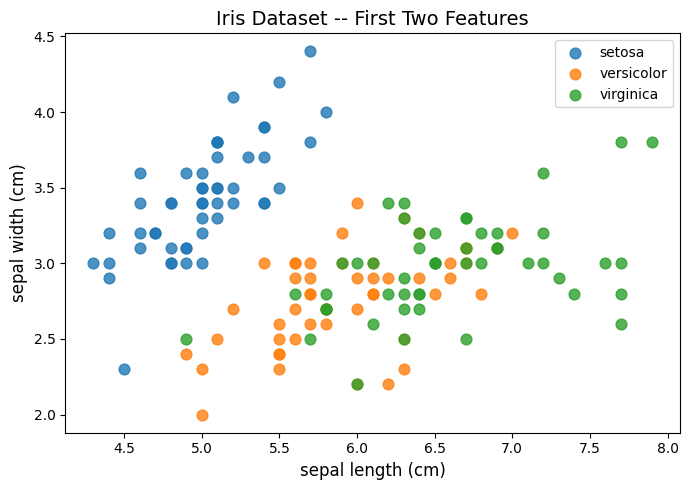

In [5]:
#选取2种数据展示相关性，检查是否可以设置为feature来预测label
X_2d = X[:, :2]

feature_x = iris.feature_names[0]
feature_y = iris.feature_names[1]

plt.figure(figsize=(7,5))
for class_idx, class_name in enumerate(iris.target_names):
  mask = (y == class_idx)
  plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=class_name, s=60, alpha=0.8)

plt.xlabel(feature_x, fontsize=12)
plt.ylabel(feature_y, fontsize=12)
plt.title('Iris Dataset -- First Two Features', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()


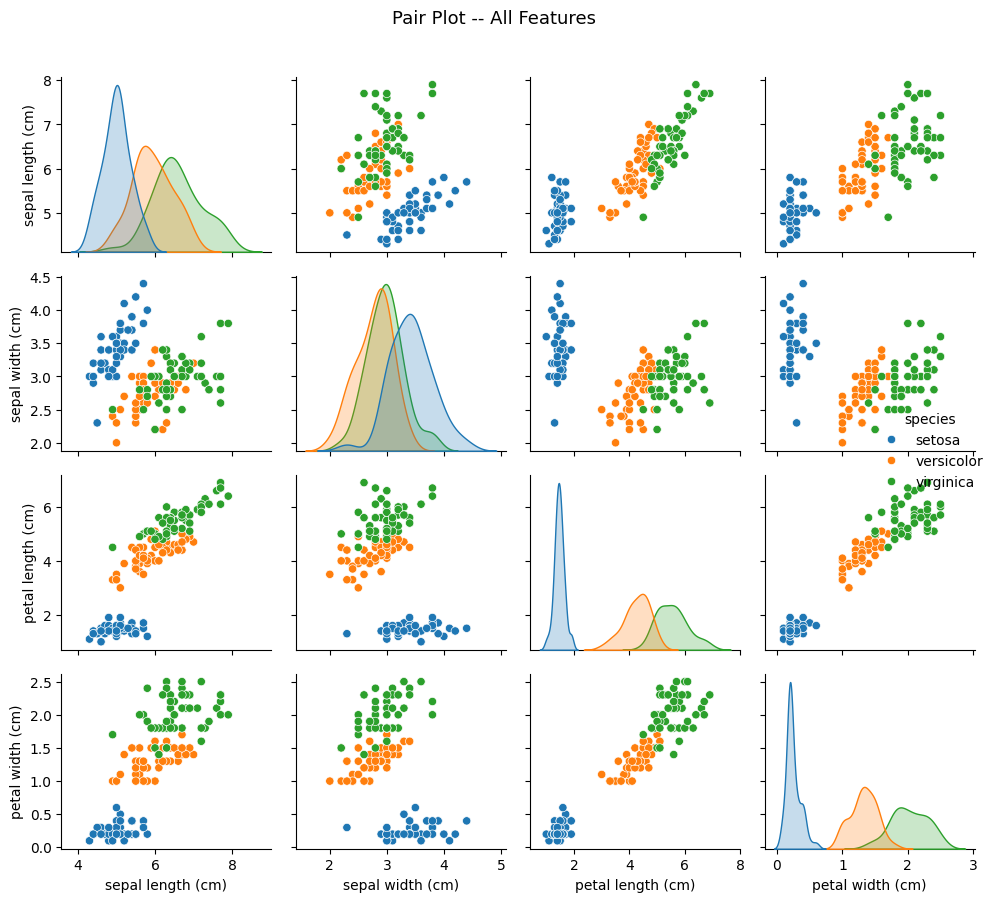

In [6]:
#观察哪些feature 更丰富， 看聚集性？
import pandas as pd

df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = [iris.target_names[i] for i in y]

sns.pairplot(df, hue='species', diag_kind='kde', height=2.2)
plt.suptitle('Pair Plot -- All Features', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_2d, y, test_size=0.2, random_state=42
)

# Logistic Regression (linear model)
model_lr2 = LogisticRegression(max_iter=200)
model_lr2.fit(X_train2, y_train2)

# Decision Tree, non-liner
model_dt2 = DecisionTreeClassifier(random_state=42)
model_dt2.fit(X_train2, y_train2)

print('Logistic Regreesion:')
print(f' Train: {model_lr2.score(X_train2, y_train2):.3f}  |'
  f'Test:{model_lr2.score(X_test2, y_test2):.3f}')
print('Decision Tree:')
print(f'Train:{model_dt2.score(X_train2, y_train2):.3f} |'
f'Test:{model_dt2.score(X_test2, y_test2):.3f}')





Logistic Regreesion:
 Train: 0.800  |Test:0.900
Decision Tree:
Train:0.942 |Test:0.633


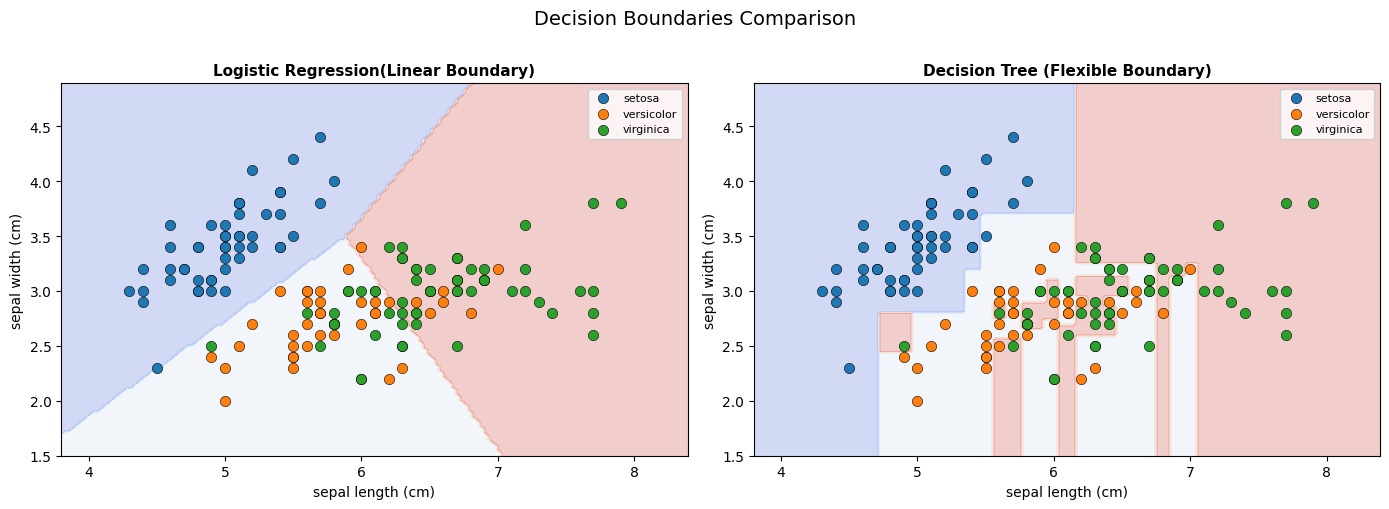

In [16]:
# Visualize decision boundary
def plot_boundary(model, X_data, y_data, title, ax):
  h = 0.03
  x_min, x_max = X_data[:,0].min()-0.5, X_data[:,0].max()+0.5
  y_min, y_max = X_data[:,1].min()-0.5, X_data[:,1].max()+0.5
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
              np.arange(y_min, y_max, h))
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

  ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
  for cls, name in enumerate(iris.target_names):
    mask = (y_data == cls)
    ax.scatter(X_data[mask, 0], X_data[mask,1],
               label=name, s=55, edgecolors='k',
               linewidths=0.4)
  ax.set_xlabel(iris.feature_names[0])
  ax.set_ylabel(iris.feature_names[1])
  ax.set_title(title, fontsize=11, fontweight='bold')
  ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_boundary(model_lr2, X_2d, y,
              'Logistic Regression(Linear Boundary)',axes[0])
plot_boundary(model_dt2, X_2d, y,
              'Decision Tree (Flexible Boundary)', axes[1])
plt.suptitle('Decision Boundaries Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


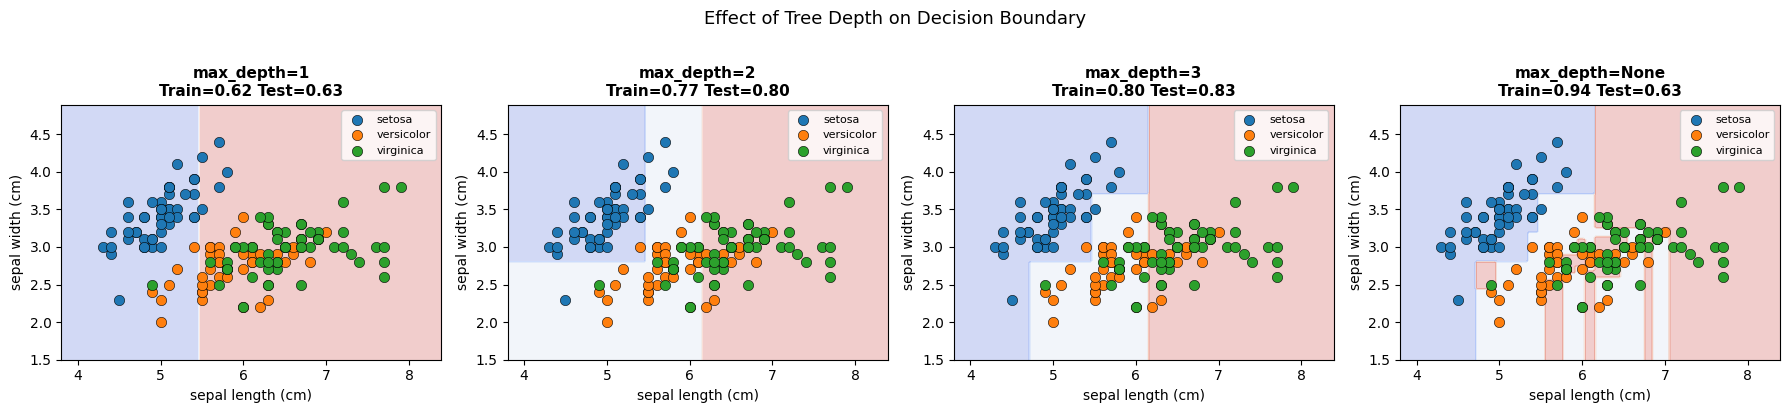

In [17]:
depths = [1, 2, 3, None]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, depth in zip(axes, depths):
  dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
  dt.fit(X_train2, y_train2)
  train_s = dt.score(X_train2, y_train2)
  test_s = dt.score(X_test2, y_test2)
  label = f'max_depth={depth}' if depth else 'max_depth=None'
  title = f'{label}\nTrain={train_s:.2f} Test={test_s:.2f}'
  plot_boundary(dt, X_2d, y, title, ax)

plt.suptitle('Effect of Tree Depth on Decision Boundary',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Meaning and reason of Overfitting